# 04 — committed 결과 심층 재해석: headline 뒤의 마진·산포·꼬리

> **지위 배너 — 재현/탐색 층.** 이 노트북이 새로 도출하는 수치는 전부 **LEDGER 미등재
> (정본 아님)** 다. 단, 이 권은 재시뮬레이션을 하지 않는다 — 모든 셀은 committed
> `results/tables/*.csv` (**정본 source**) 만 읽어 재집계하므로, 여기 수치는 "정본 source
> 에서의 파생"이다. LEDGER 행이 이미 인용한 값은 **verbatim 일치를 검증(PASS 표기)** 하고,
> 그 외 파생값을 문서(README·PLAYBOOK)로 승격하려면 LEDGER 등재 경로를 밟아야 한다.
> 규약: [`notebooks/README.md`](README.md) · [`docs/LEDGER.md`](../docs/LEDGER.md).

README 는 결론을 **headline 한 줄**로 큐레이션한다 — "dros 가 11 cell 을 이겼다",
"꼬리가 갈랐다", "사다리가 무너졌다". 이 권은 그 한 줄의 **뒤**를 본다:

| 섹션 | 질문 | source CSV |
|---|---|---|
| A. regime map 셀 해부 | 승자는 *얼마나* 이겼나 — 마진·동률·단일 seed 지배 | `hero_regime_map.csv` · `_summary.csv` |
| B. 축 02 ESS 비단조 | "정점 후 붕괴" 한 줄의 실제 궤적과 seed 산포 | `02_logging_beta.csv` |
| C. 축 07 hyperparameter 꼬리 | 평균이 아니라 꼬리가 갈랐다 — error CDF 재도출 | `07_hyperparam_ieoe.csv` |
| D. 축 15 funnel 사다리 세부 | 지표가 올라갈수록 *무엇이* 무너지나 — 분위·이벤트 수 | `15_funnel_reliability.csv` · `_events.csv` |
| E. 축 14 Λ\* 분포 | 중앙값 한 줄 뒤의 seed 산포와 참 왜곡과의 자릿수 차 | `14_lambda_sweep_breakdown.csv` |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():  # notebooks/ 또는 repo 루트 어디서 실행해도 동작
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "experiments"))

from _style import (  # noqa: E402 — figure 팔레트·규율 공용
    CONTEXT_GRAY, ESTIMATOR_COLORS, ESTIMATOR_LABELS, ORACLE_COLOR,
    apply_style, end_label, series_kwargs,
)

# _style 은 스크립트용으로 Agg 백엔드를 강제한다 — 노트북에서는 inline 렌더로 복원
%matplotlib inline
apply_style()
import matplotlib.pyplot as plt  # noqa: E402

TAB = ROOT / "results" / "tables"

## A. regime map 셀 해부 — 승자 지도의 마진과 동률 구조

README 그림 2(`results/figures/hero_regime_map.png`)의 headline 은 LEDGER `m3-hero-map`:
28-cell 승자 지도에서 **dr 9 · switch_dr 8 · dros 11 cells, DM·IPS 계열 outright 0,
tie 21/28**. 그런데 승자 지도는 1등 이름만 남긴다 — 1등이 2등을 **얼마나** 이겼는지
(마진), 어느 cell 이 사실상 동률이고 어느 cell 이 압도인지는 지도에 없다. raw CSV
(28 cell × 30 seed × 7 estimator = 5,880행)에서 cell 별 MSE 를 재도출해 해부한다.

먼저 정직성 게이트 — 재도출이 committed summary 와 **verbatim 일치**하는지 확인한다
(승자·winner MSE·사전 동률 규칙 "runner MSE ≤ winner MSE + 2·SE(MSE)").

In [2]:
hero = pd.read_csv(TAB / "hero_regime_map.csv").assign(
    sq=lambda t: (t["estimate"] - t["v_true"]) ** 2)
summ = pd.read_csv(TAB / "hero_regime_map_summary.csv")

cell_mse = (hero.groupby(["knob_value", "estimator"])["sq"]
                .agg(mse="mean", se=lambda s: s.std(ddof=1) / np.sqrt(len(s))))
for _, r in summ.iterrows():
    c = cell_mse.loc[r["knob_value"]].sort_values("mse")
    w = c.index[0]
    assert w == r["winner"] and np.isclose(c["mse"].iloc[0], r["winner_mse"], rtol=1e-12)
    partners = [e for e in c.index[1:]
                if c.loc[e, "mse"] <= c["mse"].iloc[0] + 2.0 * c.loc[w, "se"]]
    assert ";".join(partners) == (r["tie_partners"] if isinstance(r["tie_partners"], str) else "")
print("PASS — 28 cells: 승자·winner MSE·동률(2·SE 규칙) 재도출 = summary CSV verbatim")
print(f"승자 분포: {summ['winner'].value_counts().to_dict()}   tie: {int(summ['tie'].sum())}/28")

summ = summ.assign(margin=summ["runner_mse"] / summ["winner_mse"])

PASS — 28 cells: 승자·winner MSE·동률(2·SE 규칙) 재도출 = summary CSV verbatim
승자 분포: {'dros': 11, 'dr': 9, 'switch_dr': 8}   tie: 21/28


**마진 히트맵** — cell 색이 진할수록 1등이 2등을 크게 이긴 것. `≈` 는 사전 동률 규칙
발동 cell(승자 단정 불가), 우상단 약자는 게이트 다수결(T=trust, D=distrust).

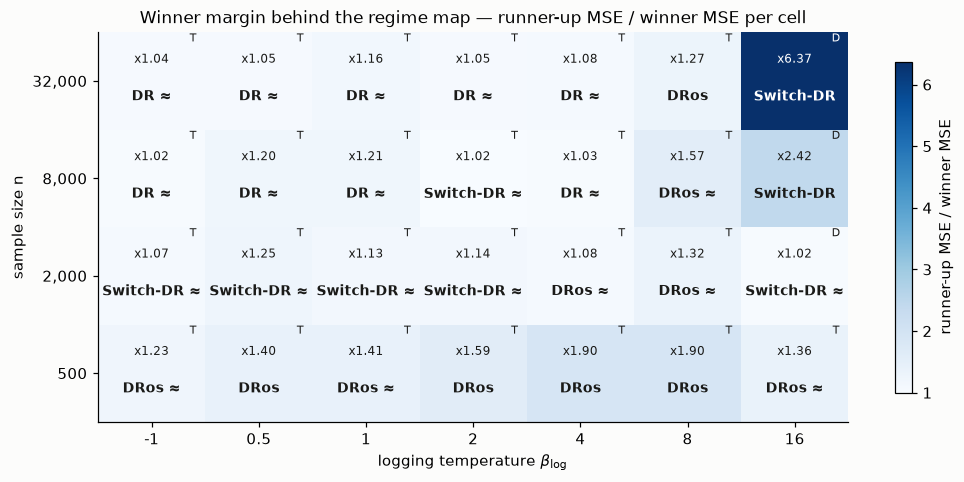

In [3]:
N_GRID = [500, 2000, 8000, 32000]
BETA_GRID = sorted(summ["beta_log"].unique())
piv = summ.pivot(index="n", columns="beta_log", values="margin").loc[N_GRID, BETA_GRID]
lut = summ.set_index("knob_value")

fig, ax = plt.subplots(figsize=(11.0, 4.6))
im = ax.imshow(piv.to_numpy(), cmap="Blues", vmin=1.0, origin="lower", aspect="auto")
for i, n in enumerate(N_GRID):
    for j, beta in enumerate(BETA_GRID):
        r = lut.loc[f"{n}x{beta:g}"]
        dark = r["margin"] > 1.0 + 0.62 * (piv.max().max() - 1.0)
        ink = "#ffffff" if dark else "#1a1a18"
        tie_mark = " ≈" if r["tie"] else ""
        ax.text(j, i - 0.16, f"{ESTIMATOR_LABELS[r['winner']]}{tie_mark}",
                ha="center", va="center", fontsize=9, fontweight="bold", color=ink)
        ax.text(j, i + 0.22, f"x{r['margin']:.2f}", ha="center", va="center",
                fontsize=8, color=ink)
        ax.text(j + 0.42, i + 0.38, {"trust": "T", "distrust": "D", "ab_fallback": "F"}[r["gate_majority"]],
                ha="right", va="bottom", fontsize=7, color=ink)
ax.set_xticks(range(len(BETA_GRID)), [f"{b:g}" for b in BETA_GRID])
ax.set_yticks(range(len(N_GRID)), [f"{n:,}" for n in N_GRID])
ax.set_xlabel(r"logging temperature $\beta_{\log}$")
ax.set_ylabel("sample size n")
ax.set_title("Winner margin behind the regime map — runner-up MSE / winner MSE per cell",
             fontsize=11)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85, label="runner-up MSE / winner MSE")
plt.show()

마진 분포를 펼치고, "한 seed 가 cell 의 MSE 를 얼마나 지배하는가"(winner 의 단일 seed
squared-error 비중)를 함께 본다 — 동률 21/28 이 왜 불가피한지가 MC 오차 구조로 보인다.

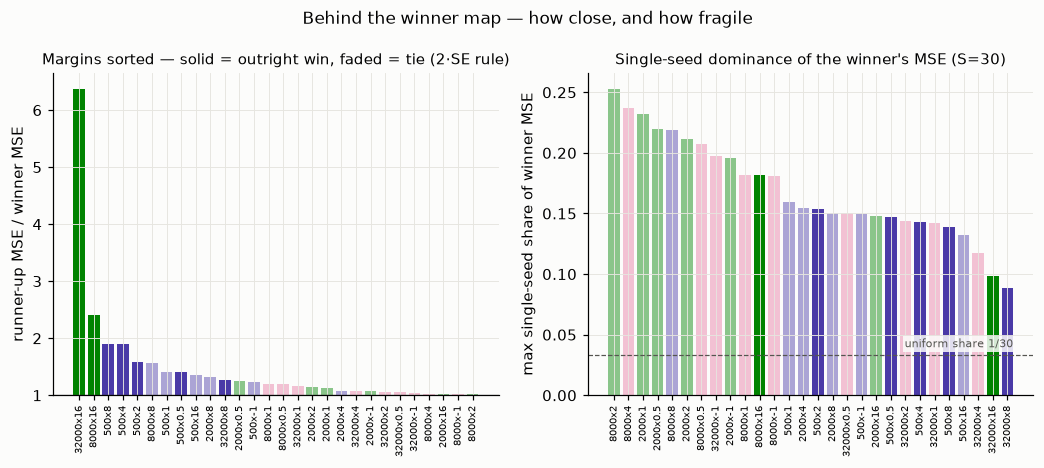

,knob_value,winner,margin,tie
kind,,,,
압도,32000x16,switch_dr,6.374,False
압도,8000x16,switch_dr,2.415,False
압도,500x8,dros,1.901,False
아슬아슬,8000x2,switch_dr,1.019,True
아슬아슬,8000x-1,dr,1.021,True
아슬아슬,2000x16,switch_dr,1.023,True


In [4]:
dom = (hero.merge(summ[["knob_value", "winner"]], on="knob_value")
           .query("estimator == winner")
           .groupby("knob_value")["sq"].apply(lambda g: g.max() / g.sum()))
summ = summ.assign(winner_seed_dom=summ["knob_value"].map(dom))

from matplotlib.colors import to_rgba  # noqa: E402

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
s = summ.sort_values("margin", ascending=False)
bar_rgba = [to_rgba(ESTIMATOR_COLORS[w], 0.45 if t else 1.0)
            for w, t in zip(s["winner"], s["tie"])]
axes[0].bar(range(28), s["margin"] - 1.0, bottom=1.0, color=bar_rgba)
axes[0].axhline(1.0, color=ORACLE_COLOR, lw=0.8)
axes[0].set_xticks(range(28), s["knob_value"], rotation=90, fontsize=6.5)
axes[0].set_ylabel("runner-up MSE / winner MSE")
axes[0].set_title("Margins sorted — solid = outright win, faded = tie (2·SE rule)", fontsize=10)

s2 = summ.sort_values("winner_seed_dom", ascending=False)
axes[1].bar(range(28), s2["winner_seed_dom"],
            color=[to_rgba(ESTIMATOR_COLORS[w], 0.45 if t else 1.0)
                   for w, t in zip(s2["winner"], s2["tie"])])
axes[1].axhline(1 / 30, color=ORACLE_COLOR, lw=0.8, ls="--")
axes[1].annotate("uniform share 1/30", xy=(27.4, 1 / 30), xytext=(0, 5),
                 textcoords="offset points", ha="right", fontsize=7.5, color=ORACLE_COLOR,
                 bbox=dict(fc="#fcfcfb", ec="none", alpha=0.85, pad=1.2))
axes[1].set_xticks(range(28), s2["knob_value"], rotation=90, fontsize=6.5)
axes[1].set_ylabel("max single-seed share of winner MSE")
axes[1].set_title("Single-seed dominance of the winner's MSE (S=30)", fontsize=10)
fig.suptitle("Behind the winner map — how close, and how fragile", y=1.03, fontsize=11)
plt.show()

top = summ.nlargest(3, "margin")[["knob_value", "winner", "margin", "tie"]]
bot = summ.nsmallest(3, "margin")[["knob_value", "winner", "margin", "tie"]]
display(pd.concat([top.assign(kind="압도"), bot.assign(kind="아슬아슬")])
          .set_index("kind").style.format({"margin": "{:.3f}"}))

읽기 (파생): 마진의 다수가 ×1.0–1.3 대 — **승자 지도의 이름 대부분은 "근소한 1등"**이고,
사전 동률 규칙이 21/28 에서 발동한 것이 정확히 이 구조다. 압도는 두 극단에서만 나온다:
**고온 β_log=16 열의 Switch-DR**(32000x16 ×6.37 · 8000x16 ×2.42 — weight 폭발 영역에서
threshold 절단의 값어치)과 **소표본 n=500 행의 DRos**(×1.4–1.9 — 분산 바닥이 귀한 영역).
한편 winner 의 MSE 자체도 한 seed 가 최대 ~25% 를 지배한다(uniform 기대 1/30≈3.3% 의
수 배) — cell 승자 이름 하나로 estimator 를 고르는 독해가 왜 위험한지의 정량 근거다.
LEDGER 의 각주 수치는 더 극적이다: **raw IPS 는 β_log=16 열에서 단일 seed 가 squared
error 의 0.7097 을 차지**한다. 재도출로 검증한다.

In [5]:
ips16 = hero[(hero["estimator"] == "ips") & hero["knob_value"].str.endswith("x16")]
share16 = ips16.groupby("knob_value")["sq"].apply(lambda g: g.max() / g.sum())
assert share16.idxmax() == "8000x16" and f"{share16.max():.4f}" == "0.7097"
print(f"PASS — raw IPS 단일 seed 지배(β_log=16 열): max = {share16.max():.4f} @ {share16.idxmax()}"
      "  (LEDGER m3-hero-map '0.7097(8000×16)' verbatim)")

ratio_500x16 = cell_mse.loc[("500x16", "ips"), "mse"] / lut.loc["500x16", "winner_mse"]
nontrust_16 = {n: int(30 - lut.loc[f"{n}x16", "n_trust"]) for n in (2000, 8000, 32000)}
assert f"{ratio_500x16:.1f}" == "70.6" and lut.loc["500x16", "n_trust"] == 21
assert list(nontrust_16.values()) == [24, 28, 30]
print(f"PASS — 게이트 검정력의 소표본 실종: 500x16 은 trust {lut.loc['500x16', 'n_trust']}/30 인데 "
      f"그 cell IPS MSE = 승자의 {ratio_500x16:.1f}×; β_log=16 non-trust 다수결 "
      f"n=2000→8000→32000: {list(nontrust_16.values())} /30")

PASS — raw IPS 단일 seed 지배(β_log=16 열): max = 0.7097 @ 8000x16  (LEDGER m3-hero-map '0.7097(8000×16)' verbatim)
PASS — 게이트 검정력의 소표본 실종: 500x16 은 trust 21/30 인데 그 cell IPS MSE = 승자의 70.6×; β_log=16 non-trust 다수결 n=2000→8000→32000: [24, 28, 30] /30


같은 β_log=16 열에서 n 이 커질수록 게이트 non-trust 가 24→28→30/30 으로 조여지는데,
n=500 만 trust 21/30 — **소표본에서는 진단 자체의 검정력이 죽는다**(위험이 가장 큰 곳에서
경보가 가장 약함). 게이트의 예보력 정본 수치는 축 08 의 LEDGER `m2-08-forecast`
(trust 4.6% vs ab_fallback 44.4% 대형오차율)다.

> **정본:** LEDGER `m3-hero-map` · 원 figure `results/figures/hero_regime_map.png`

## B. 축 02 — ESS 비단조의 실제 궤적과 seed 산포

README 축 02 headline: "**ESS 는 로깅 온도의 단조 함수가 아니다**(평가 정책과 정렬되는
구간에서 정점 후 붕괴) — MSE cliff 는 β=8 이 아니라 8→16 사이"
(README 표는 figure 링크로 인용 — 축 02 은 전용 LEDGER 수치 행이 없고, 축 01–10 완비의
근거 행은 `m2-gate` 다). 한 줄 요약이 감춘 것: 궤적의 **모양**과 **seed 산포**.
β_log 스윕(-1→16, S=40)의 ESS ratio 를 seed 별 spaghetti 로 펼친다.

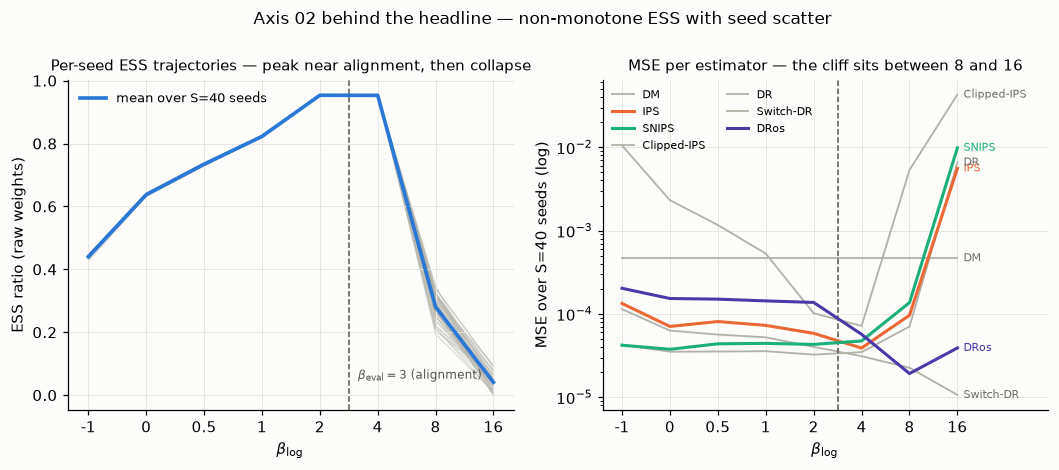

In [6]:
b02 = pd.read_csv(TAB / "02_logging_beta.csv")
GRID02 = sorted(b02["knob_value"].unique())
POS02 = {b: i for i, b in enumerate(GRID02)}
X_EVAL = POS02[2.0] + 0.5  # β_eval=3 은 grid 밖 — 2 와 4 의 중간(선형)에 참조선

ess = b02.groupby(["knob_value", "seed"])["ess_ratio_raw"].first().unstack("seed")
mseB = (b02.assign(sq=(b02["estimate"] - b02["v_true"]) ** 2)
           .groupby(["estimator", "knob_value"])["sq"].mean().unstack("knob_value"))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
xs = [POS02[b] for b in GRID02]
for seed in ess.columns:
    axes[0].plot(xs, ess[seed].loc[GRID02], color=CONTEXT_GRAY, lw=0.7, alpha=0.5, zorder=1)
axes[0].plot(xs, ess.mean(axis=1).loc[GRID02], color=ESTIMATOR_COLORS["dm"], lw=2.4, zorder=3,
             label="mean over S=40 seeds")
axes[0].axvline(X_EVAL, color=ORACLE_COLOR, ls="--", lw=1.0)
axes[0].annotate(r"$\beta_{\mathrm{eval}}=3$ (alignment)", xy=(X_EVAL, 0.05),
                 xytext=(6, 0), textcoords="offset points", fontsize=8, color=ORACLE_COLOR)
axes[0].set_xticks(xs, [f"{b:g}" for b in GRID02])
axes[0].set_xlabel(r"$\beta_{\log}$")
axes[0].set_ylabel("ESS ratio (raw weights)")
axes[0].set_title("Per-seed ESS trajectories — peak near alignment, then collapse", fontsize=10)
axes[0].legend()

EMPH = {"ips", "snips", "dros"}
for est in ESTIMATOR_COLORS:
    y = mseB.loc[est, GRID02]
    axes[1].plot(xs, y, **series_kwargs(est, est in EMPH))
    end_label(axes[1], xs[-1], y.iloc[-1], est, est in EMPH)
axes[1].axvline(X_EVAL, color=ORACLE_COLOR, ls="--", lw=1.0)
axes[1].set_yscale("log")
axes[1].set_xticks(xs, [f"{b:g}" for b in GRID02])
axes[1].set_xlim(-0.4, len(GRID02) + 0.9)
axes[1].set_xlabel(r"$\beta_{\log}$")
axes[1].set_ylabel("MSE over S=40 seeds (log)")
axes[1].set_title("MSE per estimator — the cliff sits between 8 and 16", fontsize=10)
axes[1].legend(ncol=2, fontsize=7)
fig.suptitle("Axis 02 behind the headline — non-monotone ESS with seed scatter", y=1.04,
             fontsize=11)
plt.show()

In [7]:
m = ess.mean(axis=1)
peak = m.idxmax()
print(f"[파생] mean ESS ratio: β_log=-1 에서 {m.loc[-1.0]:.3f} → 정점 {m.loc[peak]:.3f} "
      f"@ β_log={peak:g} → β_log=16 에서 {m.loc[16.0]:.3f} (정점 대비 {m.loc[16.0] / m.loc[peak]:.1%})")
print(f"[파생] seed 산포(sd): 정점 β={peak:g} 에서 {ess.loc[peak].std(ddof=1):.4f} vs "
      f"β=16 에서 {ess.loc[16.0].std(ddof=1):.4f}")
cliff = (mseB[16.0] / mseB[8.0]).sort_values(ascending=False)
print("[파생] MSE(β=16)/MSE(β=8) — cliff 배율:",
      {ESTIMATOR_LABELS[k]: round(float(v), 1) for k, v in cliff.items()})

[파생] mean ESS ratio: β_log=-1 에서 0.440 → 정점 0.953 @ β_log=2 → β_log=16 에서 0.041 (정점 대비 4.3%)
[파생] seed 산포(sd): 정점 β=2 에서 0.0007 vs β=16 에서 0.0263
[파생] MSE(β=16)/MSE(β=8) — cliff 배율: {'DR': 92.9, 'SNIPS': 72.0, 'IPS': 57.8, 'Clipped-IPS': 8.0, 'DRos': 2.0, 'DM': 1.0, 'Switch-DR': 0.5}


읽기 (파생): ESS 는 uniform 근방(β_log≈0)이 아니라 **평가 정책 β_eval=3 과 정렬되는
β_log=2–4 에서 정점**을 찍는다 — ESS 가 재는 것은 "로그의 탐색성"이 아니라 "로그·타깃
**정렬**"이라는 것이 궤적으로 보인다. 정점 이후 β=16 까지 평균이 무너질 뿐 아니라 seed
산포도 함께 커진다(같은 설정 안에서도 로그 운이 갈린다). MSE cliff 는 weighting 계열
(IPS/SNIPS)에서 β 8→16 사이 자릿수 단위로 발생하고, DM 은 bias 바닥에 눌러앉아 cliff 와
무관하다 — regime map(§A)의 저온 열에서 DM 이 동률권에 재등장하는 이유와 같은 구조다.

> **정본:** 원 figure `results/figures/02_logging_beta.png` · 축 01–10 완비 근거는
> LEDGER `m2-gate`(축 02 전용 수치 행 없음 — 세부 수치는 본 셀처럼 CSV 재도출)

## C. 축 07 — hyperparameter 꼬리: error CDF 재도출과 SLOPE 회복

README 축 07 headline 은 "평균이 아니라 **꼬리**가 갈랐다"이고, 정본 수치 행은 LEDGER
`m2-07-slope`(가혹 config β_log=8, |상대오차| 분위)다. IEOE 프로토콜: clipped-IPS·
Switch-DR·DRos 의 hyperparameter 를 무작위로 뽑아(60 draws × 30 seeds = 1,800점,
variant=`random`) "실무자가 튜닝 감 없이 골랐을 때"의 오차 분포를 만들고, SLOPE
(variant=`slope`)의 데이터 기반 선택, 무 hyperparameter 계열(variant=`fixed`)과 대조한다.
여기서는 headline 분위 뒤의 **CDF 전체**를 estimator 별로 재도출한다.

In [8]:
d07 = pd.read_csv(TAB / "07_hyperparam_ieoe.csv").assign(
    rel=lambda t: (t["estimate"] - t["v_true"]).abs() / t["v_true"])
q07 = (d07.groupby(["estimator", "variant"])["rel"]
          .agg(n="size", p50=lambda s: s.quantile(0.5), p90=lambda s: s.quantile(0.9))
          .reset_index())
display(q07.style.format({"p50": "{:.4f}", "p90": "{:.4f}"}).hide(axis="index"))

# LEDGER m2-07-slope verbatim 검증 (rtol=1e-12)
CHECKS = {
    ("clipped_ips", "random", 0.9): 0.12541997032257812,
    ("clipped_ips", "slope", 0.9): 0.05030123684860422,
    ("snips", "fixed", 0.9): 0.02908100554505259,
    ("switch_dr", "slope", 0.5): 0.005143399488432962,
    ("dros", "slope", 0.5): 0.009873919515252794,
    ("dros", "random", 0.5): 0.00594413221900361,
}
for (e, v, p), want in CHECKS.items():
    got = d07.query("estimator == @e and variant == @v")["rel"].quantile(p)
    assert np.isclose(got, want, rtol=1e-12, atol=0.0), (e, v, p, got, want)
print("PASS — LEDGER m2-07-slope 의 6개 분위 전부 verbatim 재도출 일치")

estimator,variant,n,p50,p90
clipped_ips,random,1800,0.0172,0.1254
clipped_ips,slope,30,0.0166,0.0503
dr,fixed,30,0.0073,0.0195
dros,random,1800,0.0059,0.0142
dros,slope,30,0.0099,0.0173
ips,fixed,30,0.0103,0.0182
snips,fixed,30,0.0128,0.0291
switch_dr,random,1800,0.0069,0.0157
switch_dr,slope,30,0.0051,0.0143


PASS — LEDGER m2-07-slope 의 6개 분위 전부 verbatim 재도출 일치


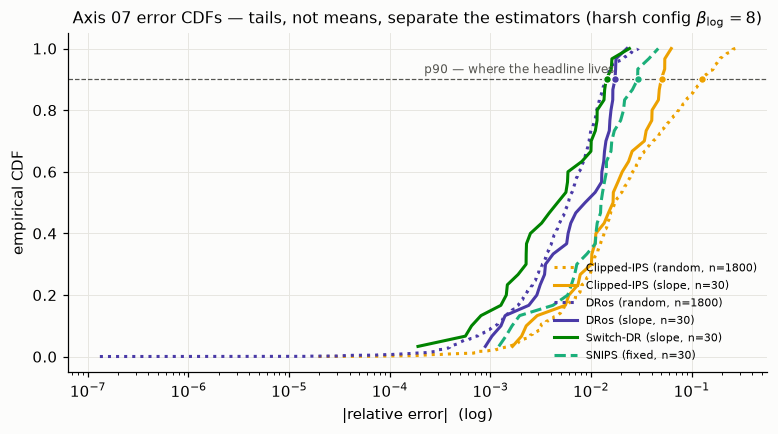

In [9]:
COMBOS = [("clipped_ips", "random"), ("clipped_ips", "slope"), ("dros", "random"),
          ("dros", "slope"), ("switch_dr", "slope"), ("snips", "fixed")]
LS = {"random": ":", "fixed": "--", "slope": "-"}

fig, ax = plt.subplots(figsize=(8.2, 4.0))
for est, var in COMBOS:
    r = np.sort(d07.query("estimator == @est and variant == @var")["rel"].to_numpy())
    cdf = np.arange(1, len(r) + 1) / len(r)
    ax.plot(r, cdf, color=ESTIMATOR_COLORS[est], ls=LS[var], lw=2.0,
            label=f"{ESTIMATOR_LABELS[est]} ({var}, n={len(r)})")
    ax.plot(np.quantile(r, 0.9), 0.9, "o", ms=5, color=ESTIMATOR_COLORS[est],
            mec="white", mew=0.8, zorder=4)
ax.axhline(0.9, color=ORACLE_COLOR, lw=0.8, ls="--")
ax.annotate("p90 — where the headline lives", xy=(2.2e-4, 0.9), xytext=(0, 4),
            textcoords="offset points", fontsize=8, color=ORACLE_COLOR)
ax.set_xscale("log")
ax.set_xlabel("|relative error|  (log)")
ax.set_ylabel("empirical CDF")
ax.set_title("Axis 07 error CDFs — tails, not means, separate the estimators "
             r"(harsh config $\beta_{\log}=8$)", fontsize=10.5)
ax.legend(fontsize=7.5, loc="lower right")
plt.show()

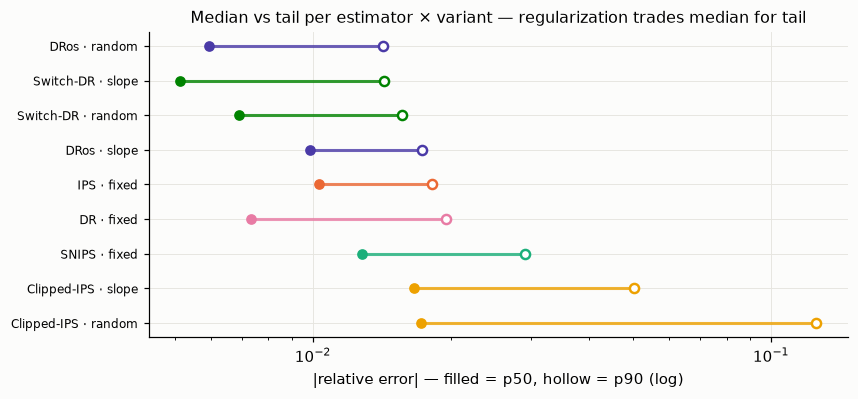

In [10]:
fig, ax = plt.subplots(figsize=(8.2, 3.6))
q07s = q07.sort_values("p90", ascending=False).reset_index(drop=True)
for i, r in q07s.iterrows():
    c = ESTIMATOR_COLORS[r["estimator"]]
    ax.plot([r["p50"], r["p90"]], [i, i], color=c, lw=2.0, alpha=0.8)
    ax.plot(r["p50"], i, "o", ms=6, color=c)
    ax.plot(r["p90"], i, "o", ms=6, color=c, mfc="white", mew=1.6)
ax.set_yticks(range(len(q07s)),
              [f"{ESTIMATOR_LABELS[r['estimator']]} · {r['variant']}" for _, r in q07s.iterrows()],
              fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("|relative error| — filled = p50, hollow = p90 (log)")
ax.set_title("Median vs tail per estimator × variant — regularization trades median for tail",
             fontsize=10.5)
plt.show()

읽기: CDF 들은 |상대오차| 2–3% 아래(중앙값 영역)에서 서로 뒤엉킨다 — **평균/중앙값으로는
순위가 갈리지 않는다**. 분리는 상단 10% 에서 일어난다: clipped-IPS 의 random-hyperparameter
꼬리 p90 = 0.1254 가 SLOPE 선택으로 **0.0503 으로 회복**되고(2.5×), Switch-DR slope 는
전 항목 최소 p50 = 0.0051 을 찍는다. 정직 병기 — dumbbell 에서 보이듯 **DRos 는 SLOPE 가
중앙값을 되레 악화**시킨다(random p50 0.0059 → slope p50 0.0099): 강규제 선택이 꼬리를
사는 대신 median 을 지불하는 거래라는 것이 분위쌍으로 드러난다.

> **정본:** LEDGER `m2-07-slope` · 원 figure `results/figures/07_hyperparam_ieoe.png`

## D. 축 15 — funnel 사다리 세부: 분위와 이벤트 수로 본 붕괴의 원인

LEDGER `m6-15-ladder`: "같은 로그에서 CTR→CVR→REV 판별한계 단조 악화(3 n × 3 estimator
전부) — **세부 분위·판별한계 원값은 source CSV 재도출**". 이 섹션이 정확히 그 재도출이다.
상대오차 분포의 중앙값 vs p90 을 지표×n 별로 펼치고, companion events CSV 로
"붕괴의 원인이 이벤트 수인가"를 검사한다.

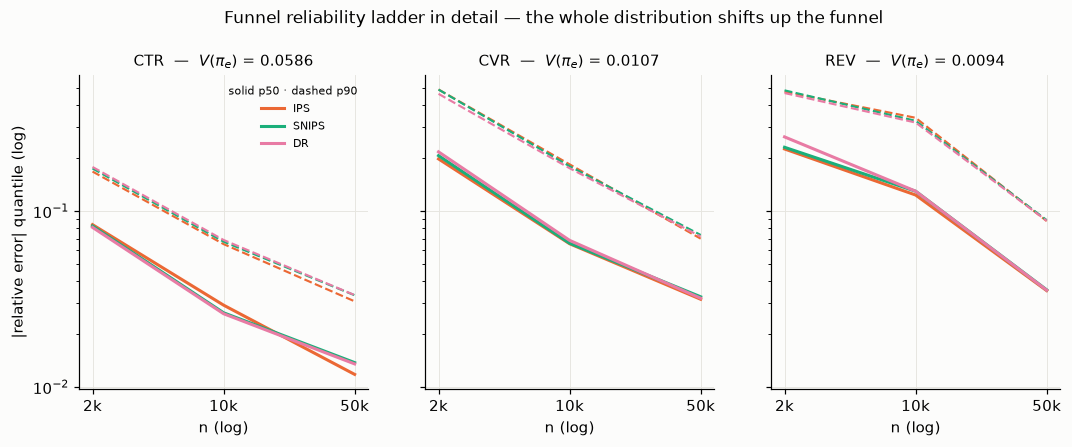

In [11]:
f15 = pd.read_csv(TAB / "15_funnel_reliability.csv")
f15 = f15.assign(
    metric=f15["variant"].str.split("|").str[0].str.replace("m:", "", regex=False),
    shrink=f15["variant"].str.contains("|q:", regex=False),
    rel=(f15["estimate"] - f15["v_true"]).abs() / f15["v_true"])
ev = pd.read_csv(TAB / "15_funnel_reliability_events.csv")

METRICS = ["ctr", "cvr", "rev"]
NS = sorted(f15["knob_value"].unique())
base = f15[~f15["shrink"]]
lad = (base.groupby(["metric", "knob_value", "estimator"])["rel"]
           .agg(p50=lambda s: s.quantile(0.5), p90=lambda s: s.quantile(0.9)))

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.7), sharey=True)
for ax, metric in zip(axes, METRICS):
    for est in ("ips", "snips", "dr"):
        sub = lad.loc[metric].xs(est, level="estimator").loc[NS]
        ax.plot(NS, sub["p90"], color=ESTIMATOR_COLORS[est], ls="--", lw=1.4)
        ax.plot(NS, sub["p50"], color=ESTIMATOR_COLORS[est], lw=2.0,
                label=ESTIMATOR_LABELS[est])
    v = base.loc[base["metric"] == metric, "v_true"].iloc[0]
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(NS, [f"{n // 1000}k" for n in NS])
    ax.xaxis.set_minor_locator(plt.NullLocator())  # log minor tick 라벨 겹침 방지
    ax.set_xlabel("n (log)")
    ax.set_title(f"{metric.upper()}  —  $V(\\pi_e)$ = {v:.4f}", fontsize=10)
axes[0].set_ylabel("|relative error| quantile (log)")
axes[0].legend(title="solid p50 · dashed p90", fontsize=7.5, title_fontsize=7.5)
fig.suptitle("Funnel reliability ladder in detail — the whole distribution shifts up the funnel",
             y=1.04, fontsize=11)
plt.show()

사다리의 통념적 설명은 "위 지표일수록 이벤트가 희소해서"다. events CSV 로 검사하면
절반만 맞다 — **0-이벤트 seed 는 하나도 없고**(전 metric×n 에서 0/40), CVR 과 REV 는
이벤트 수가 **완전히 같은데**(둘 다 전환 이벤트) 오차는 REV 가 더 크다. 즉 CTR→CVR 은
이벤트 희소화(클릭→전환)가, CVR→REV 는 같은 이벤트 수 위의 **금액(price) 가중 분산**이
사다리를 한 칸씩 무너뜨린다.

PASS — 0-이벤트 seed 비율: 전 metric×n 에서 0/40 (총 360행 중 0행)


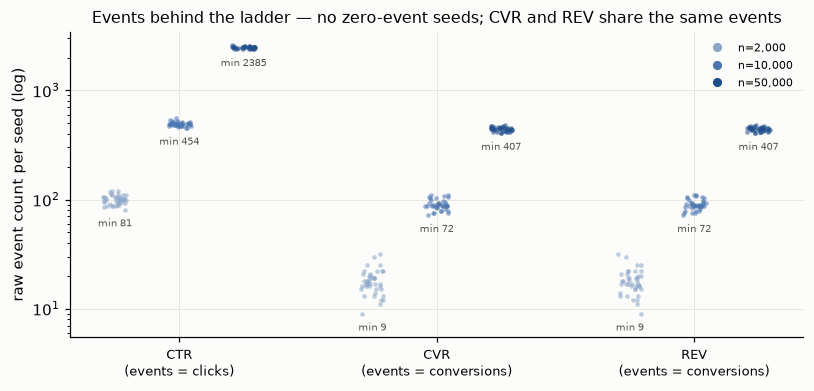

In [12]:
zero_share = (ev.assign(zero=ev["n_events"] == 0)
                .groupby(["metric", "knob"])["zero"].mean())
assert float(zero_share.max()) == 0.0
print(f"PASS — 0-이벤트 seed 비율: 전 metric×n 에서 0/40 (총 {len(ev)}행 중 0행)")

fig, ax = plt.subplots(figsize=(8.6, 3.6))
rng = np.random.default_rng(0)  # 표시용 jitter 만 — 수치 계산 아님
for i, metric in enumerate(METRICS):
    for j, n in enumerate(NS):
        g = ev.query("metric == @metric and knob == @n")["n_events"]
        x = i * (len(NS) + 1) + j + rng.uniform(-0.18, 0.18, len(g))
        color = ["#8aa5c8", "#4a76b0", "#1f4e8c"][j]
        ax.plot(x, g, "o", ms=3, alpha=0.55, color=color, mec="none")
        ax.annotate(f"min {g.min()}", xy=(i * (len(NS) + 1) + j, g.min()),
                    xytext=(0, -11), textcoords="offset points",
                    ha="center", fontsize=6.5, color="#55524c")
ax.set_yscale("log")
ax.set_ylim(bottom=5.5)  # 최솟값 주석(min 9)이 잘리지 않도록 여백 확보
ax.set_xticks([i * (len(NS) + 1) + 1 for i in range(3)],
              [f"{m.upper()}\n(events = {'clicks' if m == 'ctr' else 'conversions'})"
               for m in METRICS], fontsize=8.5)
ax.set_ylabel("raw event count per seed (log)")
ax.set_title("Events behind the ladder — no zero-event seeds; CVR and REV share the same events",
             fontsize=10.5)
from matplotlib.lines import Line2D  # noqa: E402
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=c, label=f"n={n:,}")
                   for c, n in zip(["#8aa5c8", "#4a76b0", "#1f4e8c"], NS)], fontsize=7.5)
plt.show()

In [13]:
pivot_q = (lad.reset_index()
              .pivot_table(index=["metric", "knob_value"], columns="estimator",
                           values=["p50", "p90"])
              .loc[METRICS])
display(pivot_q.style.format("{:.3f}"))

sd = base[base["estimator"] == "ips"].groupby(["metric", "knob_value"])["estimate"].std(ddof=1)
v_pi_e = base.groupby("metric")["v_true"].first()
v_pi_0 = ev.groupby("metric")["v_true_pi0"].first()
lift_sd = ((v_pi_e - v_pi_0) / sd.xs(10000, level="knob_value")).loc[METRICS]
print("[파생] n=10k IPS: true lift / seed-sd(V̂) —",
      {m: round(float(x), 2) for m, x in lift_sd.items()},
      "(σ 단위 분리 거리 — CTR 만 판별권, ladder 서사의 분위 버전)")

[파생] n=10k IPS: true lift / seed-sd(V̂) — {'ctr': 3.19, 'cvr': 1.38, 'rev': 0.74} (σ 단위 분리 거리 — CTR 만 판별권, ladder 서사의 분위 버전)


읽기 (파생): p50/p90 표에서 사다리는 지표 축으로 단조다 — 같은 n=10k 의 IPS 기준
CTR 대비 CVR·REV 의 분위가 계단식으로 나빠지고, p90 은 p50 보다 더 가파르게 벌어진다
(위 지표일수록 꼬리가 먼저 무너진다). true lift 를 seed 산포로 나눈 분리 거리(σ)도
CTR 만 판별권에 남는다 — `m6-15-ladder` 의 "n=10k 에서 CTR 판별 가능·REV 불능"의
분포 버전이다. 진단·게이트가 지표 불변(trust)인 채 이 붕괴가 일어난다는 것이 축 15 의
요점 — weight 진단은 분모(로그 기하)만 보고 분자(reward 희소성·금액 꼬리)를 못 본다.
다중 지표를 **한 게이트로 묶는** 다음 단계는 축 16(LEDGER `m6-16-gate`)이다.

> **정본:** LEDGER `m6-15-ladder` · 원 figure `results/figures/15_funnel_reliability.png`

## E. 축 14 — breakdown Λ\* 분포: 중앙값 한 줄 뒤의 산포

LEDGER `m5-14-lambda` 의 headline 은 γ 별 **Λ\* 중앙값**(γ=0.5: 1.0740 / γ=1.5: 1.0372)
이다. Λ\* 는 "MSM 감도 Λ 를 얼마나 허용하면 두 후보 정책(β=3 vs β=5)의 순위 단정이
무너지는가"의 임계값 — 중앙값 한 줄이 감춘 두 가지를 본다: ① seed 산포(S=20/γ)의 폭,
② 같은 CSV 에 기록된 **참 왜곡**(oracle true violation 분위)과의 자릿수 차이.

In [14]:
bd = pd.read_csv(TAB / "14_lambda_sweep_breakdown.csv")
GAMMA_COLORS = {0.5: "#2f6f6a", 1.5: "#8a5a2f"}

VERBATIM = {0.5: (1.0709415645333935, 1.0740359460407822, 1.0769822131366635),
            1.5: (1.0350266189592892, 1.0371960085826841, 1.0401568865134891)}
for gam, (lo, med, hi) in VERBATIM.items():
    ls = bd.loc[bd["gamma"] == gam, "lam_star"]
    assert np.isclose(ls.min(), lo, rtol=1e-12) and np.isclose(ls.median(), med, rtol=1e-12) \
        and np.isclose(ls.max(), hi, rtol=1e-12)
assert int(bd["lam_star_censored"].sum()) == 0 and int(bd["snips_rank_correct"].sum()) == 40
assert np.isclose(bd["true_rank_gap"].iloc[0], 0.0719292961063404, rtol=1e-10)
print("PASS — LEDGER m5-14-lambda verbatim: γ 별 Λ* min/median/max · censored 0/40 · "
      "snips_rank_correct 40/40 · true_rank_gap 재도출 일치")

PASS — LEDGER m5-14-lambda verbatim: γ 별 Λ* min/median/max · censored 0/40 · snips_rank_correct 40/40 · true_rank_gap 재도출 일치


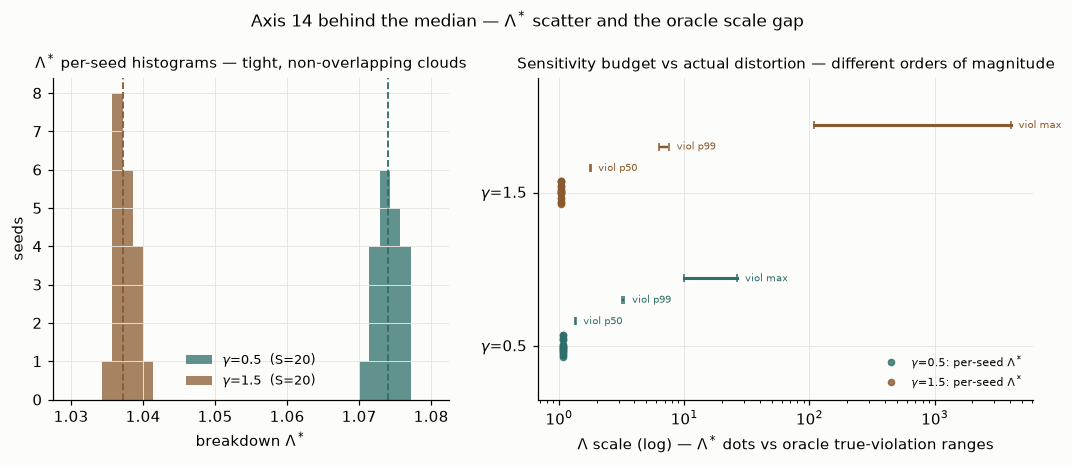

,lam_min,lam_med,lam_max,viol_p99_lo,viol_p99_hi,viol_max_hi
gamma,,,,,,
0.500000,1.0709,1.0740,1.0770,3.1610,3.3320,26.6002
1.500000,1.0350,1.0372,1.0402,6.2468,7.5689,4063.0439


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), width_ratios=[1.0, 1.25])
bins = np.linspace(1.030, 1.080, 36)
for gam in (0.5, 1.5):
    ls = bd.loc[bd["gamma"] == gam, "lam_star"]
    axes[0].hist(ls, bins=bins, color=GAMMA_COLORS[gam], alpha=0.75,
                 label=rf"$\gamma$={gam:g}  (S=20)")
    axes[0].axvline(ls.median(), color=GAMMA_COLORS[gam], lw=1.2, ls="--")
axes[0].set_xlabel(r"breakdown $\Lambda^*$")
axes[0].set_ylabel("seeds")
axes[0].set_title(r"$\Lambda^*$ per-seed histograms — tight, non-overlapping clouds",
                  fontsize=10)
axes[0].legend()

rng = np.random.default_rng(1)  # 표시용 jitter 만
OFFS = {"true_viol_p50": 0.16, "true_viol_p99": 0.30, "true_viol_max": 0.44}
for k, gam in enumerate((0.5, 1.5)):
    g = bd[bd["gamma"] == gam]
    y = k + rng.uniform(-0.08, 0.08, len(g))
    axes[1].plot(g["lam_star"], y, "o", ms=4, color=GAMMA_COLORS[gam], alpha=0.8,
                 label=rf"$\gamma$={gam:g}: per-seed $\Lambda^*$")
    for (col, off), (ls_, lw_) in zip(OFFS.items(), ((":", 1.2), ("--", 1.6), ("-", 2.0))):
        lo, hi = g[col].min(), g[col].max()
        axes[1].plot([lo, hi], [k + off] * 2, ls_, lw=lw_, color=GAMMA_COLORS[gam],
                     marker="|", ms=5)
        axes[1].annotate(col.replace("true_viol_", "viol "), xy=(hi, k + off),
                         xytext=(5, 0), textcoords="offset points", va="center",
                         fontsize=6.5, color=GAMMA_COLORS[gam])
axes[1].set_xscale("log")
axes[1].set_ylim(-0.35, 1.75)
axes[1].set_yticks([0, 1], [r"$\gamma$=0.5", r"$\gamma$=1.5"])
axes[1].set_xlabel(r"$\Lambda$ scale (log) — $\Lambda^*$ dots vs oracle true-violation ranges")
axes[1].set_title("Sensitivity budget vs actual distortion — different orders of magnitude",
                  fontsize=10)
axes[1].legend(fontsize=7.5, loc="lower right")
fig.suptitle(r"Axis 14 behind the median — $\Lambda^*$ scatter and the oracle scale gap",
             y=1.04, fontsize=11)
plt.show()

disp = (bd.groupby("gamma")
          .agg(lam_min=("lam_star", "min"), lam_med=("lam_star", "median"),
               lam_max=("lam_star", "max"), viol_p99_lo=("true_viol_p99", "min"),
               viol_p99_hi=("true_viol_p99", "max"), viol_max_hi=("true_viol_max", "max")))
display(disp.style.format("{:.4f}"))

읽기 (파생): ① **산포가 놀랄 만큼 좁다** — Λ\* 의 seed 간 전폭이 γ=0.5 에서 0.006,
γ=1.5 에서 0.005 로, 두 γ 의 구름이 전혀 겹치지 않는다. "중앙값 한 줄"이 이 축에서는
예외적으로 대표성이 높다는 뜻이고, 그 자체가 finding 이다(순위 gap 이 seed 노이즈 대비
크기 때문 — snips_rank_correct 40/40 과 정합). ② 반면 **스케일 대조는 잔혹하다**:
순위 단정은 Λ≈1.04–1.08 에서 이미 무너지는데, 같은 seed 의 oracle 참 왜곡은 p99 만
3.2–7.6 이고 per-seed max(위 표 `viol_max_hi`, 파생)는 γ=0.5 에서 26.6, γ=1.5 에선
4063 까지 튄다(극단 tail). 즉 이 설정의 진짜 교란은 순위가 버틸 수
있는 감도 예산보다 **자릿수가 다르게 크다** — "Λ-sweep 은 교정이 아니라 정직한 민감도
표시"라는 축 14 의 프레임이 분포 수준에서 재확인된다. γ 가 클수록 Λ\* 가 더 작아지는
(더 일찍 무너지는) 방향성도 두 구름의 순서로 즉시 보인다.

> **정본:** LEDGER `m5-14-lambda` · 원 figure `results/figures/14_lambda_sweep.png`

## 정리 — headline 과 그 뒤

| 섹션 | headline (README/LEDGER) | 이 권이 보여준 "그 뒤" |
|---|---|---|
| A | dr 9·switch_dr 8·dros 11, tie 21/28 (`m3-hero-map`) | 마진 다수가 ×1.0–1.3 의 근소한 1등 · winner MSE 도 단일 seed 가 최대 ~25% 지배 · raw IPS 는 0.7097 |
| B | ESS 비단조·cliff 는 8→16 사이 (figure 인용) | 정점은 β_eval 정렬 구간(β≈2–4) · 붕괴 구간에서 seed 산포 동반 확대 |
| C | 꼬리가 갈랐다·SLOPE 회복 (`m2-07-slope`) | CDF 는 중앙값 영역에서 뒤엉킴 — 분리는 p90 · DRos 는 SLOPE 가 median 을 지불 |
| D | CTR→CVR→REV 단조 악화 (`m6-15-ladder`) | 0-이벤트 seed 없음 · CTR→CVR 은 이벤트 희소화, CVR→REV 는 같은 이벤트 위 금액 분산 |
| E | Λ\* 중앙값 1.074/1.037 (`m5-14-lambda`) | seed 전폭 ≤0.006 의 좁은 구름 · 참 왜곡(p99 3.2–7.6)과 자릿수 차 |

**지위 재확인:** 이 권의 모든 신규 도출 수치는 committed CSV 에서의 **파생**이다(재현/탐색
지위, LEDGER 미등재). PASS 로 표기한 값만 LEDGER 행과 verbatim 일치가 확인된 것이며,
문서(README·PLAYBOOK)에서의 수치 인용은 언제나 **LEDGER 행 id 경유**로만 한다.